# Normalization Techniques & Gradient Clipping in Deep Learning

This notebook covers four essential stabilization techniques used in modern neural networks:

| Technique | Operates On | Primary Use Case |
|---|---|---|
| `F.normalize` | Individual vectors | Embedding spaces, cosine similarity |
| `LayerNorm` | Feature dimension per sample | Transformers, RNNs, NLP |
| `BatchNorm` | Batch dimension per feature | CNNs, large-batch supervised learning |
| `Gradient Clipping` | Gradient magnitudes | RNNs, deep nets, exploding gradients |

> **Environment**: PyTorch (available in DBR ML runtime)

In [0]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
print(f"PyTorch version: {torch.__version__}")
print("All imports successful.")

PyTorch version: 2.7.0+cpu
All imports successful.


## 1. `F.normalize(z, dim=-1)` — L2 Vector Normalization

### What it does
Projects every vector onto the **unit hypersphere** (radius = 1) along the specified dimension.

### Math
Given a vector **z** ∈ ℝᵈ:

$$\hat{z} = \frac{z}{\|z\|_2} = \frac{z}{\sqrt{\sum_{i=1}^{d} z_i^2 + \epsilon}}$$

After normalization: **‖ẑ‖₂ = 1** for every sample.

### Why `dim=-1`?
`dim=-1` means normalize along the **last dimension** (the feature/embedding dimension), so each row-vector independently gets unit norm. This is the standard for embeddings.

### Cosine Similarity Shortcut
Once normalized, dot product = cosine similarity:
$$\cos(\theta) = \hat{z}_1 \cdot \hat{z}_2$$
No expensive cosine computation needed — just a matrix multiply.

### Scenarios
- **Contrastive learning** (SimCLR, CLIP, MoCo) — projector head outputs
- **Siamese networks** — before computing similarity loss
- **Recommendation systems** — user/item embeddings for ANN search
- **NLP sentence embeddings** — before clustering or nearest-neighbour retrieval
- Does **NOT** have learnable parameters — it is a pure geometric transformation

F.normalize(z, dim=-1) Demo

Raw L2 norms (before):
tensor([3.9662, 2.7246, 2.8925, 2.5158])

L2 norms after F.normalize (all should be ~1.0):
tensor([1., 1., 1., 1.])

Manual matches F.normalize: True

Pairwise cosine similarity matrix (via dot product):
tensor([[ 1.0000,  0.2416, -0.2635,  0.0556],
        [ 0.2416,  1.0000, -0.1657,  0.0083],
        [-0.2635, -0.1657,  1.0000,  0.5004],
        [ 0.0556,  0.0083,  0.5004,  1.0000]])
Diagonal (self-similarity) should all be 1.0: tensor([1., 1., 1., 1.])


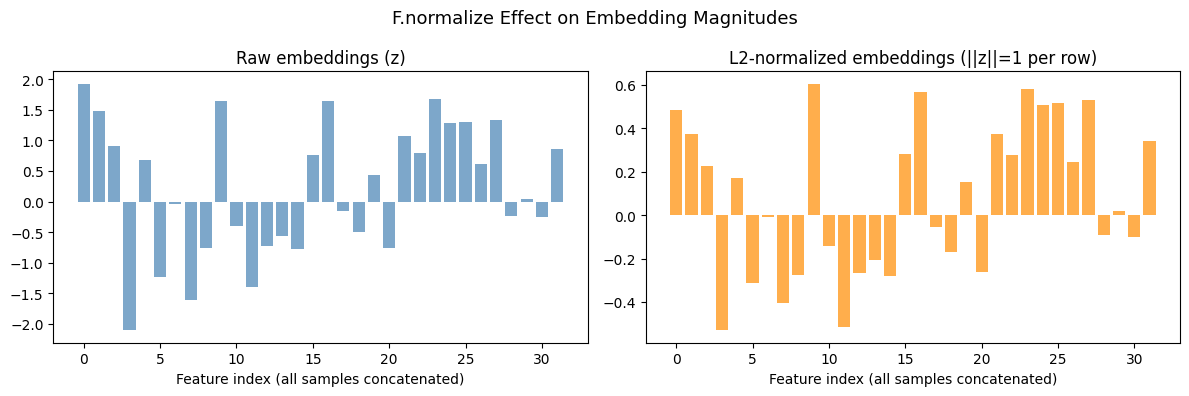

In [0]:
# ── F.normalize Implementation ──────────────────────────────────────────────

# Simulate a batch of 4 embeddings, each of dimension 8
batch_size, embed_dim = 4, 8
z = torch.randn(batch_size, embed_dim)

print("=" * 55)
print("F.normalize(z, dim=-1) Demo")
print("=" * 55)

# --- Raw norms (before normalization) ---
norms_before = z.norm(dim=-1)  # L2 norm per row
print(f"\nRaw L2 norms (before):\n{norms_before.round(decimals=4)}")

# --- Apply F.normalize ---
z_norm = F.normalize(z, p=2, dim=-1)
norms_after = z_norm.norm(dim=-1)
print(f"\nL2 norms after F.normalize (all should be ~1.0):\n{norms_after.round(decimals=6)}")

# --- Manual implementation (same math) ---
eps = 1e-12
z_manual = z / (z.norm(dim=-1, keepdim=True) + eps)
print(f"\nManual matches F.normalize: {torch.allclose(z_norm, z_manual, atol=1e-6)}")

# --- Cosine similarity via dot product after normalization ---
# dot(norm_a, norm_b) == cosine_similarity(a, b)
cos_sim_matrix = z_norm @ z_norm.T  # shape: (4, 4)
print(f"\nPairwise cosine similarity matrix (via dot product):\n{cos_sim_matrix.round(decimals=4)}")
print("Diagonal (self-similarity) should all be 1.0:", cos_sim_matrix.diag().round(decimals=6))

# --- Visualise the effect ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(embed_dim * batch_size),
            z.flatten().detach().numpy(), color='steelblue', alpha=0.7)
axes[0].set_title("Raw embeddings (z)")
axes[0].set_xlabel("Feature index (all samples concatenated)")

axes[1].bar(range(embed_dim * batch_size),
            z_norm.flatten().detach().numpy(), color='darkorange', alpha=0.7)
axes[1].set_title("L2-normalized embeddings (||z||=1 per row)")
axes[1].set_xlabel("Feature index (all samples concatenated)")

plt.suptitle("F.normalize Effect on Embedding Magnitudes", fontsize=13)
plt.tight_layout()
plt.show()

## 2. Layer Normalization (`nn.LayerNorm`)

### What it does
Normalizes across the **feature dimension** for each sample independently. Every sample in the batch gets its own mean and variance computed — no cross-sample statistics.

### Math
For a single sample with features **x** ∈ ℝᵈ:

$$\mu = \frac{1}{d}\sum_{i=1}^{d} x_i \qquad \sigma^2 = \frac{1}{d}\sum_{i=1}^{d}(x_i - \mu)^2$$

$$\hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}}$$

$$y_i = \gamma \hat{x}_i + \beta$$

- **γ** (weight) and **β** (bias) are **learnable** parameters, initialized to 1 and 0.
- **ε** ≈ 1e-5 prevents division by zero.
- Result: zero mean, unit variance per sample, then rescaled by γ, β.

### Key Property
LayerNorm is **batch-size independent** — statistics are computed per sample, not per batch. This makes it ideal for:

### Scenarios
- **Transformers** (BERT, GPT, ViT) — used after every sub-layer (attention + FFN)
- **RNNs / LSTMs** — when sequences have variable length
- **Small batch sizes** or **online learning** — where BatchNorm statistics are unreliable
- **Generative models** (Diffusion, VAEs) — stable training without batch dependency
- **NOT recommended** for CNNs on images — BatchNorm is preferred there

LayerNorm Demo

Learnable gamma (weight): tensor([1., 1., 1., 1., 1., 1., 1., 1.])
Learnable beta  (bias):   tensor([0., 0., 0., 0., 0., 0., 0., 0.])

Mean per token (should ~0): tensor([[0., 0., -0., -0., -0.],
        [-0., 0., -0., -0., 0.]], grad_fn=<RoundBackward1>)
Std  per token (should ~1): tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]], grad_fn=<RoundBackward1>)

Manual matches nn.LayerNorm: True


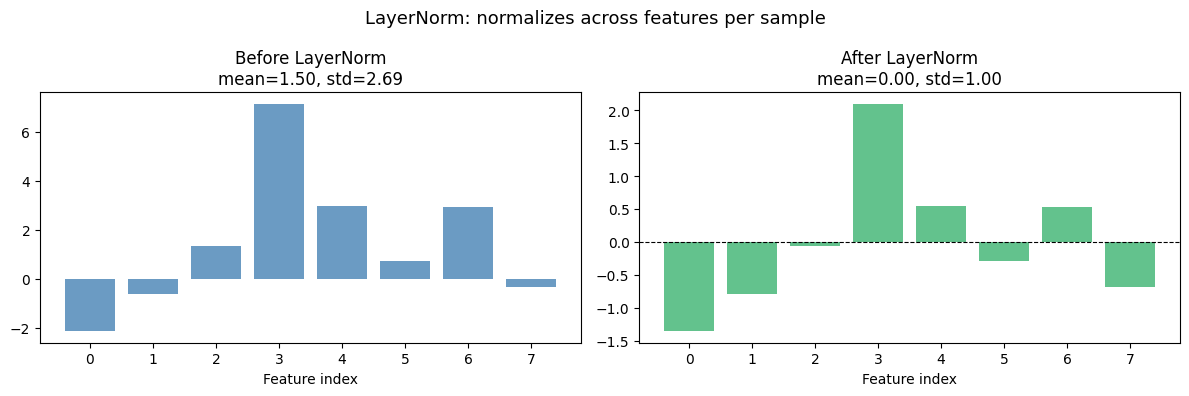


--- Transformer Post-LN pattern ---
Post-LN output shape: torch.Size([2, 5, 8])

--- Transformer Pre-LN pattern (more stable) ---
Pre-LN output shape: torch.Size([2, 5, 8])


In [0]:
# ── LayerNorm Implementation ───────────────────────────────────────────────

batch_size, seq_len, d_model = 2, 5, 8  # typical transformer dims

x = torch.randn(batch_size, seq_len, d_model) * 3 + 2  # intentionally off-scale

print("=" * 55)
print("LayerNorm Demo")
print("=" * 55)

# --- nn.LayerNorm (learnable γ, β) ---
layer_norm = nn.LayerNorm(normalized_shape=d_model, eps=1e-5)

print(f"\nLearnable gamma (weight): {layer_norm.weight.data}")
print(f"Learnable beta  (bias):   {layer_norm.bias.data}")

x_ln = layer_norm(x)

# Stats per sample per token (should be ~mean=0, std=1 before γβ rescale)
mean_after = x_ln.mean(dim=-1)
std_after  = x_ln.std(dim=-1, unbiased=False)
print(f"\nMean per token (should ~0): {mean_after.round(decimals=5)}")
print(f"Std  per token (should ~1): {std_after.round(decimals=5)}")

# --- Manual LayerNorm (no learnable params) ---
eps = 1e-5
mu  = x.mean(dim=-1, keepdim=True)
var = x.var(dim=-1, keepdim=True, unbiased=False)
x_manual = (x - mu) / torch.sqrt(var + eps)
# With γ=1, β=0 (default init), should match nn.LayerNorm output exactly
print(f"\nManual matches nn.LayerNorm: {torch.allclose(x_ln, x_manual, atol=1e-5)}")

# --- Visualise: before vs after for one sample, one token ---
sample_token = x[0, 0].detach().numpy()
sample_token_ln = x_ln[0, 0].detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(d_model), sample_token, color='steelblue', alpha=0.8)
axes[0].set_title(f"Before LayerNorm\nmean={sample_token.mean():.2f}, std={sample_token.std():.2f}")
axes[0].set_xlabel("Feature index")

axes[1].bar(range(d_model), sample_token_ln, color='mediumseagreen', alpha=0.8)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_title(f"After LayerNorm\nmean={sample_token_ln.mean():.2f}, std={sample_token_ln.std():.2f}")
axes[1].set_xlabel("Feature index")

plt.suptitle("LayerNorm: normalizes across features per sample", fontsize=13)
plt.tight_layout()
plt.show()

# --- Transformer-style usage (Post-LN vs Pre-LN) ---
print("\n--- Transformer Post-LN pattern ---")
attn_out = torch.randn(batch_size, seq_len, d_model)  # mock attention output
residual = x[..., :d_model]
out_post_ln = layer_norm(residual + attn_out)          # Add & Norm
print(f"Post-LN output shape: {out_post_ln.shape}")

print("\n--- Transformer Pre-LN pattern (more stable) ---")
out_pre_ln = residual + attn_out + layer_norm(residual)  # norm before sublayer
print(f"Pre-LN output shape: {out_pre_ln.shape}")

## 3. Batch Normalization (`nn.BatchNorm1d / BatchNorm2d`)

### What it does
Normalizes across the **batch dimension** for each feature independently. Statistics (mean, variance) are computed over the entire mini-batch per channel.

### Math
For feature **j** across a mini-batch of **N** samples:

$$\mu_j^{(B)} = \frac{1}{N}\sum_{i=1}^{N} x_{ij} \qquad \sigma_j^{2(B)} = \frac{1}{N}\sum_{i=1}^{N}(x_{ij} - \mu_j^{(B)})^2$$

$$\hat{x}_{ij} = \frac{x_{ij} - \mu_j^{(B)}}{\sqrt{\sigma_j^{2(B)} + \epsilon}}$$

$$y_{ij} = \gamma_j \hat{x}_{ij} + \beta_j$$

### Train vs Inference difference
- **Training**: uses batch statistics (μ_B, σ²_B) computed on the fly
- **Inference**: uses **running statistics** (exponential moving average accumulated during training)

$$\mu_{running} \leftarrow (1 - m)\mu_{running} + m \cdot \mu_B \quad (m = \text{momentum}, \text{default } 0.1)$$

This train/inference asymmetry is why `model.train()` / `model.eval()` matters!

### Key Properties
- Acts as a **regularizer** (slight noise from batch statistics — reduces need for Dropout)
- Allows **higher learning rates** (smooths the loss landscape)
- Depends on **batch size** — small batches → noisy/unreliable statistics

### Scenarios
- **CNNs** (ResNet, VGG, EfficientNet) — standard choice for image models
- **Large batch supervised learning** (batch size ≥ 16 recommended)
- **Tabular deep nets** with stable batch sizes
- **Avoid** in RNNs (variable seq length), Transformers, or batch size = 1

BatchNorm1d Demo

Input shape: torch.Size([8, 4])
Per-feature mean (before): tensor([ 0.1000,  3.8700, 11.2900, 15.1200])
Per-feature std  (before): tensor([1.1600, 1.1200, 1.9200, 3.7200])

Per-feature mean (after):  tensor([-0., 0., 0., 0.])
Per-feature std  (after):  tensor([1., 1., 1., 1.])

Learnable gamma: tensor([1., 1., 1., 1.])
Learnable beta:  tensor([0., 0., 0., 0.])

Running mean (EMA, updated during train): tensor([0.0100, 0.3870, 1.1290, 1.5120])
Running var  (EMA, updated during train): tensor([1.0550, 1.0430, 1.3210, 2.4820])

Max abs diff (train vs eval mode): 11.0289
(Non-zero because train uses batch stats, eval uses running EMA stats)

Manual BN matches nn.BatchNorm1d (excl. γβ): True


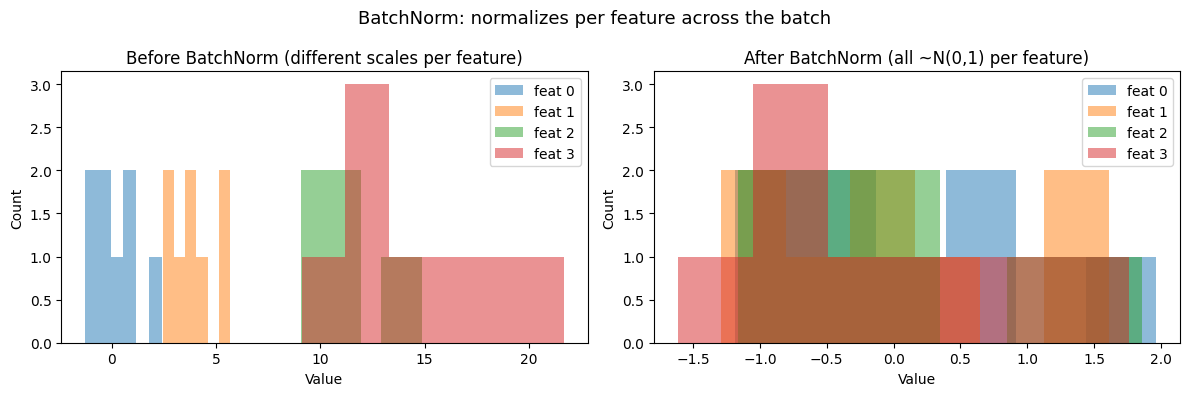


--- BatchNorm2d (CNN use case) ---
Input shape:  torch.Size([16, 32, 8, 8])
Output shape: torch.Size([16, 32, 8, 8]) (same shape, stats over N x H x W per channel)


In [0]:
# ── BatchNorm Implementation ───────────────────────────────────────────────

batch_size, num_features = 8, 4

# Intentionally skewed scale per feature
x = torch.stack([
    torch.randn(batch_size) * (i + 1) + (i * 5)
    for i in range(num_features)
], dim=1)  # shape: (8, 4)

print("=" * 55)
print("BatchNorm1d Demo")
print("=" * 55)
print(f"\nInput shape: {x.shape}")
print(f"Per-feature mean (before): {x.mean(dim=0).round(decimals=2)}")
print(f"Per-feature std  (before): {x.std(dim=0, unbiased=False).round(decimals=2)}")

# --- nn.BatchNorm1d ---
bn = nn.BatchNorm1d(num_features=num_features, eps=1e-5, momentum=0.1)
bn.train()  # IMPORTANT: use batch stats during training

x_bn = bn(x)
print(f"\nPer-feature mean (after):  {x_bn.mean(dim=0).round(decimals=5).detach()}")
print(f"Per-feature std  (after):  {x_bn.std(dim=0, unbiased=False).round(decimals=5).detach()}")
print(f"\nLearnable gamma: {bn.weight.data}")
print(f"Learnable beta:  {bn.bias.data}")

# Running stats tracked internally
print(f"\nRunning mean (EMA, updated during train): {bn.running_mean.round(decimals=3)}")
print(f"Running var  (EMA, updated during train): {bn.running_var.round(decimals=3)}")

# --- Train vs Eval mode difference ---
bn.eval()  # switches to running statistics
x_eval = bn(x)
print(f"\nMax abs diff (train vs eval mode): {(x_bn - x_eval).abs().max().item():.4f}")
print("(Non-zero because train uses batch stats, eval uses running EMA stats)")

# --- Manual BatchNorm (no γ/β) ---
bn.train()
eps = 1e-5
mu_b  = x.mean(dim=0, keepdim=True)                       # (1, num_features)
var_b = x.var(dim=0, keepdim=True, unbiased=False)        # (1, num_features)
x_manual_bn = (x - mu_b) / torch.sqrt(var_b + eps)
print(f"\nManual BN matches nn.BatchNorm1d (excl. γβ): {torch.allclose(x_manual_bn, x_bn.detach(), atol=1e-4)}")

# --- Visualise per-feature distributions ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(num_features):
    axes[0].hist(x[:, i].detach().numpy(), bins=6, alpha=0.5, label=f"feat {i}")
    axes[1].hist(x_bn[:, i].detach().numpy(), bins=6, alpha=0.5, label=f"feat {i}")

axes[0].set_title("Before BatchNorm (different scales per feature)")
axes[1].set_title("After BatchNorm (all ~N(0,1) per feature)")
for ax in axes:
    ax.legend()
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
plt.suptitle("BatchNorm: normalizes per feature across the batch", fontsize=13)
plt.tight_layout()
plt.show()

# --- BatchNorm2d for CNNs ---
print("\n--- BatchNorm2d (CNN use case) ---")
cnn_feat = torch.randn(16, 32, 8, 8)  # (N, C, H, W)
bn2d = nn.BatchNorm2d(num_features=32)
out2d = bn2d(cnn_feat)
print(f"Input shape:  {cnn_feat.shape}")
print(f"Output shape: {out2d.shape} (same shape, stats over N x H x W per channel)")

## 4. Gradient Clipping

### What it does
Caps the **magnitude of gradients** before the optimizer step to prevent **exploding gradients**.

### Two Variants

#### A. Clip by Global Norm (`torch.nn.utils.clip_grad_norm_`)

Compute the **global L2 norm** across all parameter gradients:

$$G = \left\| \mathbf{g} \right\|_2 = \sqrt{\sum_{p} \sum_{i} g_{pi}^2}$$

If G > max_norm, scale every gradient down proportionally:

$$\mathbf{g} \leftarrow \mathbf{g} \cdot \frac{\text{max\_norm}}{G}$$

This **preserves gradient direction**, only reduces magnitude. If G ≤ max\_norm, gradients are unchanged.

#### B. Clip by Value (`torch.nn.utils.clip_grad_value_`)

Clip each gradient element independently:

$$g_{pi} \leftarrow \text{clip}(g_{pi},\; -\text{clip\_value},\; +\text{clip\_value})$$

This **does NOT preserve direction** — use with caution.

### Why Exploding Gradients Happen
In deep or recurrent networks, gradients are products of many Jacobians:

$$\frac{\partial L}{\partial h_0} = \prod_{t=1}^{T} W^T \cdot \frac{\partial L}{\partial h_T}$$

If the spectral radius of **W > 1**, the product grows exponentially → exploding gradients.

### Scenarios
- **RNNs / LSTMs / GRUs** — standard practice (max_norm=1.0 or 5.0)
- **Transformers** — commonly used (max_norm=1.0 in BERT, GPT)
- **Very deep networks** — when gradients spike during early training
- **RL policy gradients** — noisy reward signals cause spikes
- Not needed for shallow nets with BatchNorm — BN implicitly smooths gradients

Gradient Clipping Demo

Global gradient norm BEFORE clipping: 1.3370
Global gradient norm AFTER  clip_grad_norm_ (max=1.0): 1.3370
Verified global norm after clip: 0.999999

Max absolute gradient after clip_grad_value_ (clip=0.5): 0.427862

--- Typical Training Loop with Gradient Clipping ---
Pre-clip gradient norms over 20 steps:
[1.3058, 1.2761, 1.2479, 1.2212, 1.196, 1.1724, 1.1502, 1.1296, 1.1104, 1.0928, 1.0766, 1.062, 1.0488, 1.0371, 1.0269, 1.018, 1.0105, 1.0043, 0.9994, 0.9956]


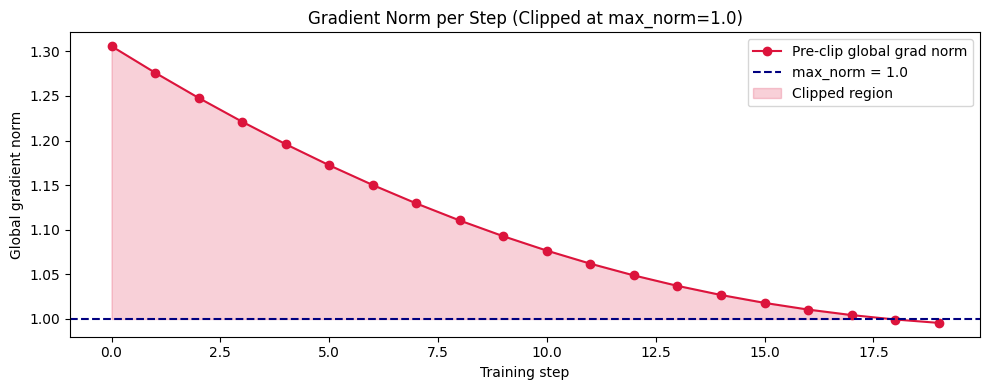

In [0]:
# ── Gradient Clipping Implementation ────────────────────────────────────────────

# --- Build a simple RNN-like model to demonstrate ---
class SimpleRNN(nn.Module):
    def __init__(self, input_size=10, hidden_size=20, output_size=1):
        super().__init__()
        self.rnn   = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc    = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

model     = SimpleRNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

# Simulate input + target
seq_len    = 30
batch_size = 16
x_in       = torch.randn(batch_size, seq_len, 10)
y_target   = torch.randn(batch_size, 1)

print("=" * 55)
print("Gradient Clipping Demo")
print("=" * 55)

# ---- Without clipping ----
optimizer.zero_grad()
pred  = model(x_in)
loss  = loss_fn(pred, y_target)
loss.backward()

grad_norms_before = []
for p in model.parameters():
    if p.grad is not None:
        grad_norms_before.append(p.grad.norm().item())

global_norm_before = sum(g**2 for g in grad_norms_before) ** 0.5
print(f"\nGlobal gradient norm BEFORE clipping: {global_norm_before:.4f}")

# ---- Clip by norm (preserves direction) ----
max_norm    = 1.0
total_norm  = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)
print(f"Global gradient norm AFTER  clip_grad_norm_ (max={max_norm}): {total_norm:.4f}")

grad_norms_after = [p.grad.norm().item() for p in model.parameters() if p.grad is not None]
global_norm_after = sum(g**2 for g in grad_norms_after) ** 0.5
print(f"Verified global norm after clip: {global_norm_after:.6f}")

optimizer.step()

# ---- Clip by value (element-wise) ----
optimizer.zero_grad()
loss2 = loss_fn(model(x_in), y_target)
loss2.backward()

clip_value = 0.5
torch.nn.utils.clip_grad_value_(model.parameters(), clip_value=clip_value)

max_grad_after_value_clip = max(
    p.grad.abs().max().item() for p in model.parameters() if p.grad is not None
)
print(f"\nMax absolute gradient after clip_grad_value_ (clip={clip_value}): {max_grad_after_value_clip:.6f}")

# ---- Training loop with clipping (best practice pattern) ----
print("\n--- Typical Training Loop with Gradient Clipping ---")
norm_log = []
for step in range(20):
    optimizer.zero_grad()
    pred = model(x_in)
    loss = loss_fn(pred, y_target)
    loss.backward()

    norm_before_clip = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    norm_log.append(norm_before_clip.item())  # log pre-clip norm for monitoring
    optimizer.step()

print(f"Pre-clip gradient norms over 20 steps:\n{[round(n, 4) for n in norm_log]}")

# ---- Plot pre-clip gradient norms ----
plt.figure(figsize=(10, 4))
plt.plot(norm_log, marker='o', color='crimson', label='Pre-clip global grad norm')
plt.axhline(1.0, color='navy', ls='--', label='max_norm = 1.0')
plt.fill_between(range(20), norm_log, 1.0,
                 where=[n > 1.0 for n in norm_log],
                 alpha=0.2, color='crimson', label='Clipped region')
plt.title("Gradient Norm per Step (Clipped at max_norm=1.0)")
plt.xlabel("Training step")
plt.ylabel("Global gradient norm")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Side-by-Side Comparison & Decision Guide

| | `F.normalize` | `LayerNorm` | `BatchNorm` | Gradient Clipping |
|---|---|---|---|---|
| **Normalizes** | Vector to unit sphere | Features per sample | Batch per feature | Gradient magnitudes |
| **Learnable params** | None | γ, β (per feature) | γ, β (per feature) | None |
| **Batch-size dep.** | No | No | **Yes** | No |
| **Train/eval differ** | No | No | **Yes** | No |
| **Typical placement** | After projection head | After attention/FFN | After conv/linear | Before `optimizer.step()` |
| **Fixes** | Scale variance in embedding space | Internal covariate shift | Internal covariate shift | Exploding gradients |

### Quick Decision Tree

```
Are you normalizing EMBEDDINGS for similarity search?
  YES → F.normalize(z, dim=-1)

Are you building a TRANSFORMER or RNN?
  YES → LayerNorm

Are you building a CNN with large batches (>=16)?
  YES → BatchNorm2d

Are you training a deep/recurrent net and seeing loss spikes?
  YES → Add Gradient Clipping (clip_grad_norm_, max_norm=1.0)
```

### Common Combinations
- **Transformer**: Pre-LayerNorm + Gradient Clipping (max_norm=1.0)
- **Contrastive model** (SimCLR): BatchNorm in encoder + `F.normalize` in projector
- **LSTM language model**: LayerNorm + Gradient Clipping (max_norm=5.0)
- **ResNet (CNN)**: BatchNorm2d only, no clipping needed typically

Step  0 | Loss: -0.9960 | Avg cosine similarity: 0.9959
Step  5 | Loss: -0.9972 | Avg cosine similarity: 0.9972
Step 10 | Loss: -0.9980 | Avg cosine similarity: 0.9980
Step 15 | Loss: -0.9985 | Avg cosine similarity: 0.9985
Step 20 | Loss: -0.9988 | Avg cosine similarity: 0.9988
Step 25 | Loss: -0.9991 | Avg cosine similarity: 0.9990


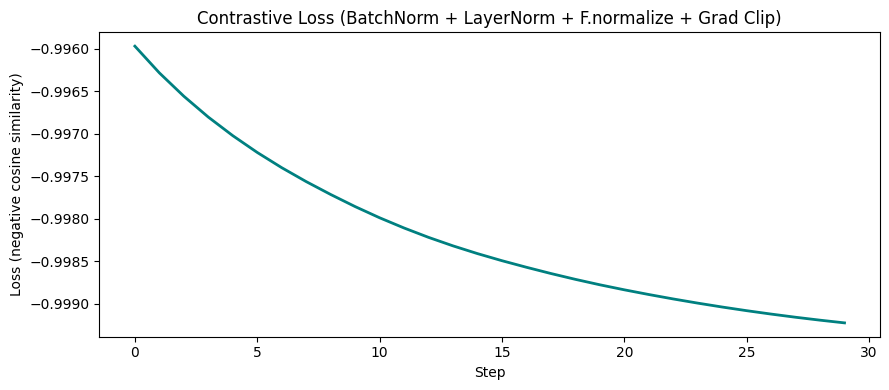


Final embedding norms (all should be 1.0): tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
Final embedding shape: torch.Size([32, 64])


In [0]:
# ── End-to-End: All 4 Techniques in One Training Loop ────────────────────────────

class EncoderWithAllNorms(nn.Module):
    """
    Encoder that uses:
    - BatchNorm1d  : on raw input features
    - LayerNorm    : after the transformer-style projection
    - F.normalize  : on the final embedding for contrastive/similarity use
    """
    def __init__(self, input_dim=16, hidden_dim=32, embed_dim=64):
        super().__init__()
        self.bn   = nn.BatchNorm1d(input_dim)          # stabilise raw features
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim)
        )
        self.ln   = nn.LayerNorm(embed_dim)            # stabilise projected features

    def forward(self, x):
        x = self.bn(x)                                 # BatchNorm on input
        z = self.proj(x)                               # Project to embedding space
        z = self.ln(z)                                 # LayerNorm on embedding
        z = F.normalize(z, p=2, dim=-1)                # L2-normalize for cosine similarity
        return z


batch_size, input_dim, embed_dim = 32, 16, 64
model_full = EncoderWithAllNorms(input_dim=input_dim, embed_dim=embed_dim)
optimizer  = torch.optim.AdamW(model_full.parameters(), lr=1e-3)

# Dummy contrastive-style loss: maximize similarity of paired samples
x1 = torch.randn(batch_size, input_dim)
x2 = x1 + 0.1 * torch.randn_like(x1)  # slightly perturbed positives

loss_history = []
for step in range(30):
    model_full.train()
    optimizer.zero_grad()

    z1 = model_full(x1)  # normalized embeddings
    z2 = model_full(x2)

    # Simple contrastive loss: minimize negative cosine similarity of pairs
    loss = -F.cosine_similarity(z1, z2).mean()
    loss.backward()

    # ── GRADIENT CLIPPING before optimizer step ──
    torch.nn.utils.clip_grad_norm_(model_full.parameters(), max_norm=1.0)

    optimizer.step()
    loss_history.append(loss.item())

    if step % 5 == 0:
        model_full.eval()
        with torch.no_grad():
            z1_e = model_full(x1)
            z2_e = model_full(x2)
            avg_cos = F.cosine_similarity(z1_e, z2_e).mean().item()
        print(f"Step {step:2d} | Loss: {loss.item():.4f} | Avg cosine similarity: {avg_cos:.4f}")

# Plot training loss
plt.figure(figsize=(9, 4))
plt.plot(loss_history, color='teal', lw=2)
plt.title("Contrastive Loss (BatchNorm + LayerNorm + F.normalize + Grad Clip)")
plt.xlabel("Step")
plt.ylabel("Loss (negative cosine similarity)")
plt.tight_layout()
plt.show()

# Final embedding stats
model_full.eval()
with torch.no_grad():
    z_final = model_full(x1)
print(f"\nFinal embedding norms (all should be 1.0): {z_final.norm(dim=-1).round(decimals=6)}")
print(f"Final embedding shape: {z_final.shape}")